# Decision Trees

A Decision Tree is a supervised learning algorithm that splits data into branches based on feature values, forming a tree-like structure. Each internal node represents a decision rule (e.g., “Is radius < 5.5?”), and each leaf node represents a classification outcome.

Key steps in the algorithm:

#### Find the Best Split:

For every feature, test all possible threshold values.

Calculate the Gini impurity for each split:

$Gini = 1 - \sum_{k=1}^K (p_k)^2$ 

 where $p_k$ is the proportion of samples in class k.

#### Choose the Split:

Select the feature and threshold that minimize Gini impurity (i.e., make the data as pure as possible).

#### Recursion:

Repeat the splitting process on the left and right branches until:

- Maximum depth is reached,

- All samples in a node are of the same class,

- Or there are no valid splits left.

#### Prediction:

For a new sample, traverse the tree by checking the feature thresholds at each node until reaching a leaf, which gives the predicted class.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

We’ll use the Breast Cancer Wisconsin dataset from sklearn.datasets

This dataset contains information about tumors, including whether they are malignant or benign, based on various features extracted from cell nuclei.

For simplicity and visualization purposes, we’ll focus on just two features:

- Mean Radius

- Mean Texture

These features create a 2D feature space, where we can visually inspect how the decision tree algorithm partitions the data. While this choice limits visualization of the full predictive power of the dataset, it allows us to clearly observe the decision boundaries and interpret the classification results. 

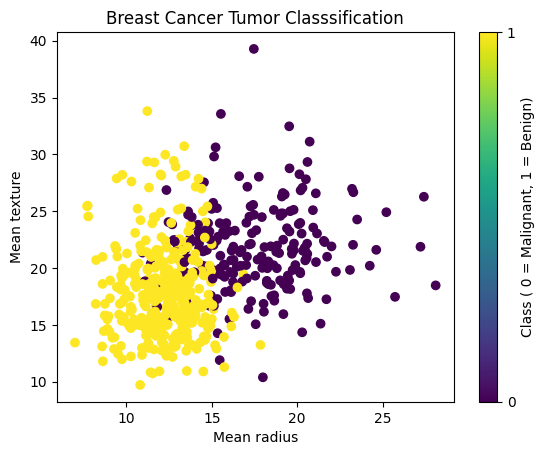

In [2]:
#Loading data
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')  # Pick two features to plot
plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])
cbar.set_label('Class ( 0 = Malignant, 1 = Benign)')

plt.show()

In [3]:
class SimpleDecisionTree:
    def __init__(self, max_depth=2):
        self.max_depth = max_depth  # limit how deep the tree can grow
        self.tree = None  # will hold the root node

    def fit(self, X, y):
        # Start building the tree from the root
        self.tree = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        # If all labels are the same, or max depth is reached — return a leaf
        if depth == self.max_depth or len(set(y)) == 1:
            return np.bincount(y).argmax()  # return the majority class

        # Try to find the best split
        best_feat, best_thresh = self._find_best_split(X, y)

        # If no valid split is found, return a leaf with the majority class
        if best_feat is None:
            return np.bincount(y).argmax()

        # Split data
        left_idx = X[:, best_feat] < best_thresh
        right_idx = ~left_idx  # everything else

        # Recursively build left and right subtrees
        left = self._build_tree(X[left_idx], y[left_idx], depth + 1)
        right = self._build_tree(X[right_idx], y[right_idx], depth + 1)

        # Return this decision node
        return (best_feat, best_thresh, left, right)

    def _gini(self, y):
        # Calculate Gini impurity of a label distribution
        probs = np.bincount(y) / len(y)
        return 1 - np.sum(probs ** 2)

    def _find_best_split(self, X, y):
        best_gini = 1  # worst possible impurity
        best_feat, best_thresh = None, None

        # Iterate over all features
        for feat in range(X.shape[1]):
            thresholds = np.unique(X[:, feat])
            for t in thresholds:
                # Divide labels based on threshold
                left = y[X[:, feat] < t]
                right = y[X[:, feat] >= t]

                # Skip empty splits
                if len(left) == 0 or len(right) == 0:
                    continue

                # Weighted Gini impurity
                g = (len(left) * self._gini(left) + len(right) * self._gini(right)) / len(y)

                # Keep the split with lowest impurity
                if g < best_gini:
                    best_gini = g
                    best_feat = feat
                    best_thresh = t

        return best_feat, best_thresh

    def predict(self, X):
        # Predict each sample individually
        return np.array([self._predict_one(x, self.tree) for x in X])

    def _predict_one(self, x, node):
        # If we're at a leaf node, just return the label
        if not isinstance(node, tuple):
            return node

        # Otherwise, unpack the node and recurse
        feat, thresh, left, right = node
        if x[feat] < thresh:
            return self._predict_one(x, left)
        else:
            return self._predict_one(x, right)

In [4]:
#Implementing a Decision Tree
custom_tree = SimpleDecisionTree(max_depth=3)
custom_tree.fit(X_train, y_train)
y_pred_custom = custom_tree.predict(X_test)
custom_accuracy = accuracy_score(y_test, y_pred_custom)
print(f"Accuracy: {custom_accuracy:.4f}")

Accuracy: 0.9386


In [5]:
#Implementing scikit-learn Decision Tree
sklearn_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
sklearn_tree.fit(X_train, y_train)
y_pred_sklearn = sklearn_tree.predict(X_test)
sklearn_accuracy = accuracy_score(y_test, y_pred_sklearn)
print(f"Accuracy: {sklearn_accuracy:.4f}")

Accuracy: 0.9474


In [6]:
#Comparing Results
print("\nComparison:")
print(f"Custom Decision Tree correct: {(y_pred_custom == y_test).sum()} / {len(y_test)}")
print(f"Sklearn Decision Tree correct: {(y_pred_sklearn == y_test).sum()} / {len(y_test)}")


Comparison:
Custom Decision Tree correct: 107 / 114
Sklearn Decision Tree correct: 108 / 114


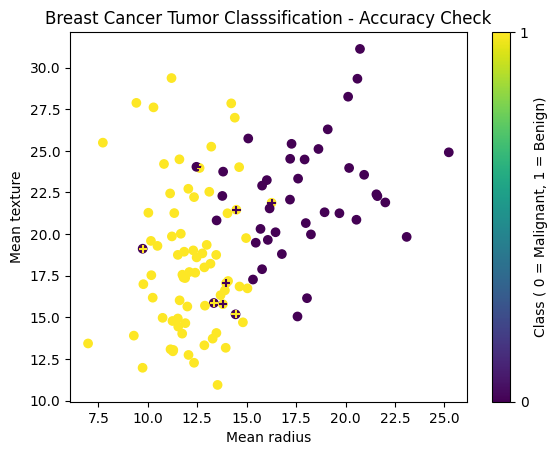

In [7]:
plt.scatter(X_test[:, 0], X_test[:, 1], c = y_pred_custom)
plt.scatter(X_test[:, 0], X_test[:, 1], c = y_test, marker = '+')

plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification - Accuracy Check')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])
cbar.set_label('Class ( 0 = Malignant, 1 = Benign)')
     

The accuracy of both models is very similar which is great! However, it is important to notice that this model would issue a fair amount of false negatives, which are very dangerous and allow for the development of the disease.